In [3]:
import pandas as pd

# Load Dataset
df = pd.read_csv("/content/ecommerce_customer_support_dataset_after_eda.csv")

print(df.head())
print(df.shape)
print(df.info())

   Ticket_ID                                    Customer_Query  \
0       1001                               My order is delayed   
1       1002  Where is my order? and product size is incorrect   
2       1003                                    Payment failed   
3       1004         Delivery date changed and damaged product   
4       1005                                Card payment error   

         Category     Department Priority Sentiment  Confidence_Score  \
0  Delivery Issue  Delivery Team      Low  Positive              0.60   
1    Order Status  Order Support   Medium  Negative              0.87   
2   Payment Issue   Payment Team      Low  Negative              0.67   
3  Delivery Issue  Delivery Team      Low  Positive              0.75   
4   Payment Issue   Payment Team     High  Negative              0.86   

   Escalation_Count  Previous_Transfers  Resolution_Time_Hours Misrouted  
0                 0                   2                     55       Yes  
1             

   Ticket_ID                                    Customer_Query  \
0       1001                               My order is delayed   
1       1002  Where is my order? and product size is incorrect   
2       1003                                    Payment failed   
3       1004         Delivery date changed and damaged product   
4       1005                                Card payment error   

         Category     Department Priority Sentiment  Confidence_Score  \
0  Delivery Issue  Delivery Team      Low  Positive              0.60   
1    Order Status  Order Support   Medium  Negative              0.87   
2   Payment Issue   Payment Team      Low  Negative              0.67   
3  Delivery Issue  Delivery Team      Low  Positive              0.75   
4   Payment Issue   Payment Team     High  Negative              0.86   

   Escalation_Count  Previous_Transfers  Resolution_Time_Hours Misrouted  
0                 0                   2                     55       Yes  
1             

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,984 (11.66 KB)

 Trainable params: 2,984 (11.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3395 - loss: 1.6930 - val_accuracy: 0.5506 - val_loss: 1.2346
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7064 - loss: 0.9364 - val_accuracy: 0.8263 - val_loss: 0.7283
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8708 - loss: 0.5583 - val_accuracy: 0.8719 - val_loss: 0.4600
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9147 - loss: 0.3519 - val_accuracy: 0.9006 - val_loss: 0.3067
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9297 - loss: 0.2449 - val_accuracy: 0.9225 - val_loss: 0.2370
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9320 - loss: 0.1896 - val_accuracy: 0.9231 - val_loss: 0.1875
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9367 - loss: 0.1610 - val_accuracy: 0.9306 - val_loss: 0.1665
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9369 - loss: 0.1451 - val_accuracy: 0.

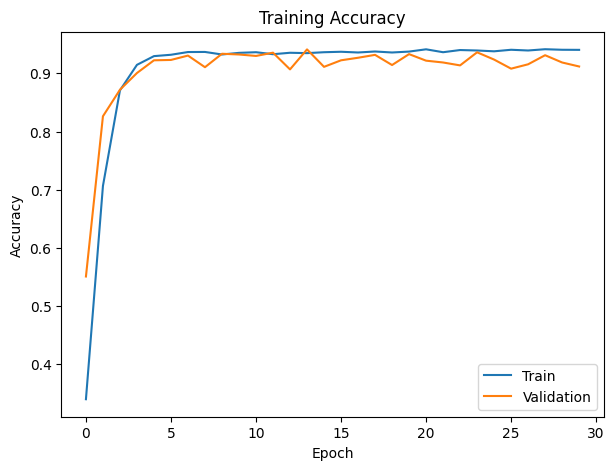

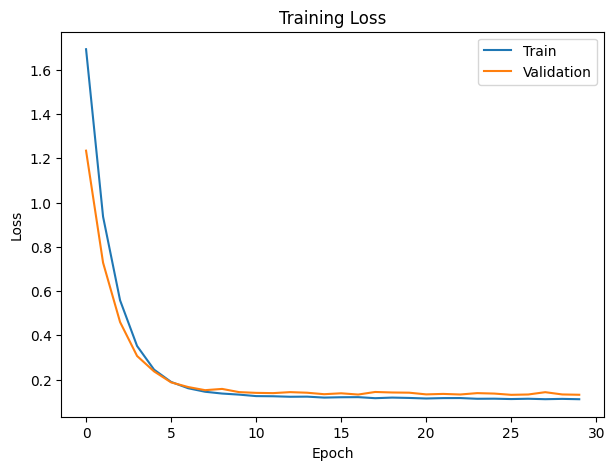

Model Saved Successfully


In [3]:
# ==============================
# MODULE 1 : Import Libraries
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# ==============================
# MODULE 2 : Load Dataset
# ==============================

df = pd.read_csv("/ecommerce_customer_support_dataset_after_eda.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print(df.head())

print("\nColumns:")
print(df.columns.tolist())

# ==============================
# MODULE 3 : Drop Ticket_ID
# ==============================

if 'Ticket_ID' in df.columns:
    df.drop('Ticket_ID', axis=1, inplace=True)

# ==============================
# MODULE 4 : Encode Categorical Columns
# ==============================

label_encoders = {}

for col in df.columns:

    if df[col].dtype == 'object':

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col].astype(str))

        label_encoders[col] = le

print(df.head())

# ==============================
# MODULE 5 : Feature & Target
# ==============================

# The column 'Ticket_Type' does not exist in the DataFrame.
# Please choose an existing column from the DataFrame for the target variable 'y'.
# For example, if 'Category' is the intended target, you would use:
# X = df.drop("Category", axis=1)
# y = df["Category"]

# For now, let's assume 'Category' is the intended target, but you should verify this.
# If a different column is your target, please replace 'Category' with the correct column name.
X = df.drop("Category", axis=1)
y = df["Category"]


# ==============================
# MODULE 6 : Feature Scaling
# ==============================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# ==============================
# MODULE 7 : Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

# ==============================
# MODULE 8 : ANN Model
# ==============================

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))

model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

model.summary()

# ==============================
# MODULE 9 : Train Model
# ==============================

history = model.fit(

    X_train,

    y_train,

    epochs=30,

    batch_size=32,

    validation_split=0.2

)

# ==============================
# MODULE 10 : Test Accuracy
# ==============================

loss, accuracy = model.evaluate(X_test, y_test)

print("\nAccuracy =", accuracy)

# ==============================
# MODULE 11 : Prediction
# ==============================

prediction = model.predict(X_test)

predicted_class = np.argmax(prediction, axis=1)

# ==============================
# MODULE 12 : Evaluation
# ==============================

print("\nClassification Report")

print(classification_report(y_test, predicted_class))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, predicted_class))

# ==============================
# MODULE 13 : Accuracy Graph
# ==============================

plt.figure(figsize=(7,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

# ==============================
# MODULE 14 : Loss Graph
# ==============================

plt.figure(figsize=(7,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

# ==============================
# MODULE 15 : Save Model
# ==============================

model.save("ann_ticket_classifier.h5")

print("Model Saved Successfully")